# ME 3300 Lab 10 — The Thrust Stand as a Dynamic System: Solution Notebook (TA)

**TA use only.** Runs against the synthetic data in `../Data/` (regenerate
with `generate_synthetic_data.py`; it shares its true-system constants with
Lab 09's generator). Executing this notebook validates every code block in
the Lab 10 manual — its saved figures ARE the manual's example figures.

Part numbering mirrors the manual. Part 1 (hardware checkout) has no
analysis; the code starts at Part 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif']
plt.rcParams['font.size'] = 10

date_str = '2026-11-17'   # students: use your lab date

## Part-2: Tap Test — Identify the Rig's Second-Order Dynamics

Prop OFF, motor unpowered. A pen-tap on the motor plate is an impulse
input; the load cell rings down at the rig's damped natural frequency.
`find_peaks` locates the successive maxima; peak spacing gives $\omega_d$
and the log decrement gives $\zeta$.

In [2]:
n_peaks = 10                      # use the first 10 clean peaks
fn_runs, zeta_runs = [], []

for run in (1, 2, 3):
    d = np.loadtxt(f'../Data/TapTest_Run{run}.csv',
                   delimiter=',', comments='#')
    t, v = d[:, 0], d[:, 1]

    baseline = v[:400].mean()             # cell voltage before the tap
    y = v - baseline

    idx0 = np.argmax(np.abs(y) > 0.05)    # first sample after the tap
    peaks, _ = find_peaks(y[idx0:], height=0.02, distance=15)
    peaks = peaks[:n_peaks] + idx0        # back to full-record indexing

    tp, Ap = t[peaks], y[peaks]

    # damped frequency from mean peak spacing
    Td = np.diff(tp).mean()
    omega_d = 2 * np.pi / Td

    # log decrement -> damping ratio -> natural frequency
    delta = np.mean(np.log(Ap[:-1] / Ap[1:]))
    zeta = delta / np.sqrt(4 * np.pi**2 + delta**2)
    omega_n = omega_d / np.sqrt(1 - zeta**2)

    fn_runs.append(omega_n / (2 * np.pi))
    zeta_runs.append(zeta)
    print(f"run {run}: fn = {fn_runs[-1]:.2f} Hz, zeta = {zeta:.4f}")

fn_runs, zeta_runs = np.array(fn_runs), np.array(zeta_runs)
t2 = stats.t.ppf(0.975, df=2)
fn_CI = t2 * fn_runs.std(ddof=1) / np.sqrt(3)
zeta_CI = t2 * zeta_runs.std(ddof=1) / np.sqrt(3)
print(f"fn = {fn_runs.mean():.2f} ± {fn_CI:.2f} Hz, "
      f"zeta = {zeta_runs.mean():.4f} ± {zeta_CI:.4f}  (95% CI, n = 3)")

run 1: fn = 41.89 Hz, zeta = 0.0371
run 2: fn = 42.28 Hz, zeta = 0.0323
run 3: fn = 41.89 Hz, zeta = 0.0366
fn = 42.02 ± 0.55 Hz, zeta = 0.0353 ± 0.0065  (95% CI, n = 3)


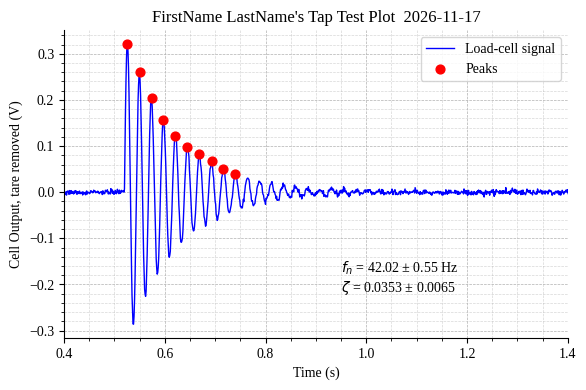

In [3]:
# ringdown figure (run 1)
d = np.loadtxt('../Data/TapTest_Run1.csv', delimiter=',', comments='#')
t, v = d[:, 0], d[:, 1]
y = v - v[:400].mean()
idx0 = np.argmax(np.abs(y) > 0.05)
peaks, _ = find_peaks(y[idx0:], height=0.02, distance=15)
peaks = peaks[:n_peaks] + idx0

fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')
ax.plot(t, y, 'b-', lw=1, label='Load-cell signal')
ax.scatter(t[peaks], y[peaks], s=40, c='red', zorder=3, label='Peaks')

ax.set_xlim(0.4, 1.4)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell Output, tare removed (V)')
ax.set_title(f"FirstName LastName's Tap Test Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right')
ax.text(0.55, 0.15,
        f"$f_n$ = {fn_runs.mean():.2f} ± {fn_CI:.2f} Hz\n"
        f"$\\zeta$ = {zeta_runs.mean():.4f} ± {zeta_CI:.4f}",
        transform=ax.transAxes)

fig.savefig('../Figures/FirstName_LastName_Lab10_TapTest.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab10_TapTest.pdf',
            bbox_inches='tight')
plt.show()

## Part-3: Throttle Step Response — the Motor as a First-Order System

Load last week's calibration (good calibrations are assets — load, don't
redo), convert both channels, find the step from the current jump, and
extract the thrust time constant by linearizing the exponential.

In [4]:
# TA note: students' path is '../../Lab_09/Data/loadcell_calibration_coeffs.csv'
coeffs = np.loadtxt('../../../Lab_09/SolutionPackage_TA/Data/'
                    'loadcell_calibration_coeffs.csv',
                    delimiter=',', comments='#')     # [c1 N/V, c0 N]

tare = np.loadtxt('../Data/MotorOffTare.csv', delimiter=',', comments='#')
v_tare = tare[:, 1].mean()
print(f"c1 = {coeffs[0]:.4f} N/V, tare = {v_tare:.4f} V")

c1 = 9.8920 N/V, tare = 0.0893 V


In [5]:
def step_analysis(fname):
    """Return t, thrust (N), step time, T0, Tss, tau for one record."""
    d = np.loadtxt(fname, delimiter=',', comments='#')
    t, v_c, v_i = d[:, 0], d[:, 1], d[:, 2]

    F = np.polyval(coeffs, v_c) - np.polyval(coeffs, v_tare)
    I = (v_i - 2.5) / 0.100

    # the commanded step shows up instantly in current: detect it there
    jump = np.abs(np.diff(I))
    i_step = np.argmax(jump > 1.5) + 1          # designed >> 5-sigma noise
    t0 = t[i_step]

    T0  = F[t < t0 - 0.05].mean()               # pre-step steady state
    Tss = F[t > t0 + 0.60].mean()               # post-step steady state

    # linearize: y = (Tss-F)/(Tss-T0) = exp(-(t-t0)/tau) -> ln y is a line.
    # Window design matters: y in (0.10, 0.90) keeps the clean part of the
    # decay, and t < t0 + 0.3 s keeps settled-noise samples (which sometimes
    # wander above 0.10 by chance) from poisoning the fit.
    y = (Tss - F) / (Tss - T0)
    mask = (t > t0) & (t < t0 + 0.30) & (y > 0.10) & (y < 0.90)
    pc = np.polyfit(t[mask] - t0, np.log(y[mask]), 1)
    tau = -1 / pc[0]
    return t, F, t0, T0, Tss, tau


taus_up, taus_dn = [], []
for run in (1, 2, 3):
    *_, tau_u = step_analysis(f'../Data/StepUp_Run{run}.csv')
    *_, tau_d = step_analysis(f'../Data/StepDown_Run{run}.csv')
    taus_up.append(tau_u)
    taus_dn.append(tau_d)
    print(f"run {run}: tau_up = {tau_u*1000:.1f} ms, "
          f"tau_down = {tau_d*1000:.1f} ms")

taus_up, taus_dn = np.array(taus_up), np.array(taus_dn)
tau_CI = t2 * taus_up.std(ddof=1) / np.sqrt(3)
print(f"tau_up = {taus_up.mean()*1000:.1f} ± {tau_CI*1000:.1f} ms (95% CI)")

run 1: tau_up = 59.2 ms, tau_down = 136.0 ms
run 2: tau_up = 56.6 ms, tau_down = 135.5 ms
run 3: tau_up = 58.9 ms, tau_down = 135.8 ms
tau_up = 58.2 ± 3.6 ms (95% CI)


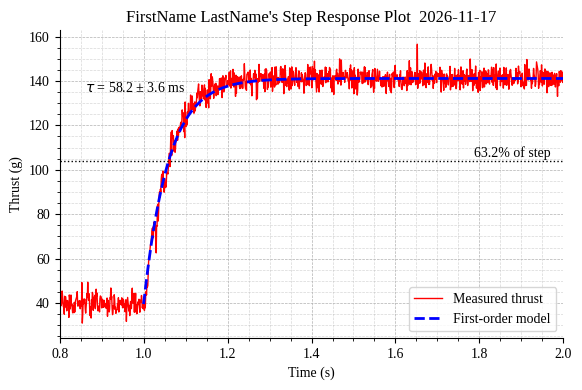

In [6]:
# step-response figure (up-step, run 1) with first-order model overlay
t, F, t0, T0, Tss, tau = step_analysis('../Data/StepUp_Run1.csv')
g = F / 9.81 * 1000

fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')
ax.plot(t, g, 'r-', lw=1, label='Measured thrust')

t_m = np.linspace(t0, t.max(), 400)
model = Tss - (Tss - T0) * np.exp(-(t_m - t0) / tau)
ax.plot(t_m, model / 9.81 * 1000, 'b--', lw=2, label='First-order model')

g63 = (T0 + 0.632 * (Tss - T0)) / 9.81 * 1000
ax.axhline(g63, color='k', ls=':', lw=1)
ax.text(t0 + 0.97, g63 + 2, '63.2% of step', ha='right')

ax.set_xlim(t0 - 0.2, t0 + 1.0)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Thrust (g)')
ax.set_title(f"FirstName LastName's Step Response Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')
ax.text(0.05, 0.80,
        f"$\\tau$ = {taus_up.mean()*1000:.1f} ± {tau_CI*1000:.1f} ms",
        transform=ax.transAxes)

fig.savefig('../Figures/FirstName_LastName_Lab10_StepResponse.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab10_StepResponse.pdf',
            bbox_inches='tight')
plt.show()

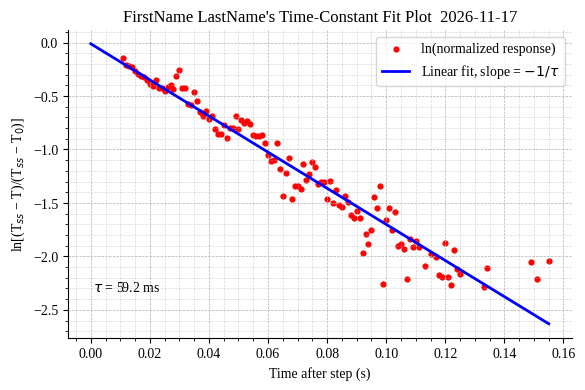

In [7]:
# the linearization itself — the straight line IS the evidence for
# first-order behavior
t, F, t0, T0, Tss, tau = step_analysis('../Data/StepUp_Run1.csv')
y = (Tss - F) / (Tss - T0)
mask = (t > t0) & (t < t0 + 0.30) & (y > 0.10) & (y < 0.90)
pc = np.polyfit(t[mask] - t0, np.log(y[mask]), 1)

fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')
ax.scatter(t[mask] - t0, np.log(y[mask]), s=12, c='red',
           label='ln(normalized response)')
x = np.linspace(0, (t[mask] - t0).max(), 50)
ax.plot(x, np.polyval(pc, x), 'b-', lw=2,
        label=f'Linear fit, slope = $-1/\\tau$')

ax.set_xlabel('Time after step (s)')
ax.set_ylabel('ln[(T$_{ss}$ − T)/(T$_{ss}$ − T$_0$)]')
ax.set_title(f"FirstName LastName's Time-Constant Fit Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right')
ax.text(0.05, 0.15, f"$\\tau$ = {-1/pc[0]*1000:.1f} ms",
        transform=ax.transAxes)

fig.savefig('../Figures/FirstName_LastName_Lab10_TauFit.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab10_TauFit.pdf',
            bbox_inches='tight')
plt.show()

## Part-4: Bandwidth Separation — Do We Trust the Thrust Measurement?

The rig rings at $f_n$; the motor responds with bandwidth
$f_{bw} = 1/(2\pi\tau)$. The measurement is trustworthy because these are
well separated — the stand is effectively rigid at the speeds the motor can
actually change thrust.

In [8]:
f_bw = 1 / (2 * np.pi * taus_up.mean())
sep = fn_runs.mean() / f_bw
print(f"motor bandwidth      = {f_bw:.2f} Hz")
print(f"rig natural frequency = {fn_runs.mean():.1f} Hz")
print(f"separation ratio      = {sep:.1f}x")
print("\nWhy no 42 Hz ringing in the step? The motor's inertia filters the"
      "\ncommanded step down to ~3 Hz bandwidth before it ever reaches the"
      "\nrig — the rig only rings when hit faster than it can follow (the"
      "\ntap).")

motor bandwidth      = 2.73 Hz
rig natural frequency = 42.0 Hz
separation ratio      = 15.4x

Why no 42 Hz ringing in the step? The motor's inertia filters the
commanded step down to ~3 Hz bandwidth before it ever reaches the
rig — the rig only rings when hit faster than it can follow (the
tap).


## Part-5: Execute the Hover Design Point

The capstone moment: Lab 09's curve said 38% throttle hovers the 240 g
quadcopter (60 g per motor). Command it, hold 5 s, and check whether the
design target falls inside the measurement's confidence interval.

In [9]:
d = np.loadtxt('../Data/HoverTest.csv', delimiter=',', comments='#')
t, v_c, v_i = d[:, 0], d[:, 1], d[:, 2]
F = np.polyval(coeffs, v_c) - np.polyval(coeffs, v_tare)
g_thrust = F / 9.81 * 1000

# consecutive samples are correlated, so a plain std/sqrt(N) CI would be
# dishonestly narrow. Average 1-second blocks and treat the BLOCKS as the
# independent samples.
g_trim = g_thrust[t >= 1.0]
n_blk = len(g_trim) // 1000                 # whole 1-second blocks
blocks = g_trim[:n_blk * 1000].reshape(n_blk, 1000).mean(axis=1)
g_mean = blocks.mean()
g_CI = (stats.t.ppf(0.975, df=n_blk - 1)
        * blocks.std(ddof=1) / np.sqrt(n_blk))

target = 60.0
err = (g_mean - target) / target * 100
print(f"measured hover thrust = {g_mean:.1f} ± {g_CI:.1f} g (95% CI)")
print(f"design target = {target:.1f} g -> {err:+.1f}% error")
I_h = ((v_i - 2.5) / 0.100)[t > 1.0].mean()
print(f"hover current = {I_h:.2f} A -> flight time ~ "
      f"{0.850/(4*I_h)*60:.1f} min on an 850 mAh pack")

measured hover thrust = 62.6 ± 0.1 g (95% CI)
design target = 60.0 g -> +4.4% error
hover current = 1.05 A -> flight time ~ 12.2 min on an 850 mAh pack


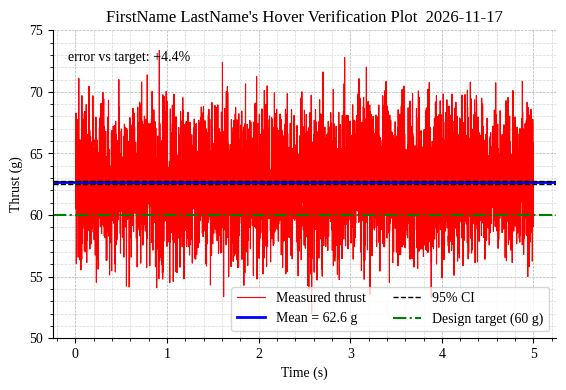

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.0), facecolor='white')
ax.plot(t, g_thrust, 'r-', lw=0.8, label='Measured thrust')
ax.axhline(g_mean, color='blue', lw=2, label=f'Mean = {g_mean:.1f} g')
ax.axhline(g_mean + g_CI, color='k', ls='--', lw=1, label='95% CI')
ax.axhline(g_mean - g_CI, color='k', ls='--', lw=1)
ax.axhline(60.0, color='green', ls='-.', lw=1.5,
           label='Design target (60 g)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Thrust (g)')
ax.set_ylim(50, 75)
ax.set_title(f"FirstName LastName's Hover Verification Plot  {date_str}")
ax.grid(which='major', ls='--', lw=0.5)
ax.grid(which='minor', ls='--', lw=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right', ncol=2)
ax.text(0.03, 0.90, f"error vs target: {err:+.1f}%",
        transform=ax.transAxes)

fig.savefig('../Figures/FirstName_LastName_Lab10_HoverVerification.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab10_HoverVerification.pdf',
            bbox_inches='tight')
plt.show()

## Grading / checking notes (TA)

- **Tap test**: fn ≈ 42 Hz, ζ ≈ 0.03–0.04. If fn comes out ~21 or ~84 Hz
  they double-counted or skipped peaks (check their `distance` argument).
  ζ from ppf(0.95) errors doesn't apply here, but watch for students using
  only 2–3 peaks (noisy δ) or including the clipped first peak.
- **Step response**: τ_up ≈ 55–60 ms; τ_down ≈ 130–140 ms — the down-step
  is genuinely ~2.3× slower (physical: the ESC can't push current
  backwards, so spin-down coasts on prop drag alone while spin-up gets
  active motor torque). The asymmetry is the intended discussion, not an
  error. If τ is ~5 ms they fit the current channel; if τ blows up to
  ~1000 ms their fit window let settled-noise samples in (check the
  t < t0 + 0.3 s cap).
- **Log-linear fit**: should be visibly straight. Curvature at early times
  (< ~10 ms) is real (electrical lag + rig) — that's why the window starts
  at y = 0.9.
- **Bandwidth separation**: ~10–14×. The "why no ringing in the step"
  question is the key concept check.
- **Hover verification**: mean ≈ 62–63 g vs 60 g target → +4–5% error, and
  the target is typically OUTSIDE the (tight) measurement CI. This is the
  intended discussion: the CI covers *precision* of this rig's measurement,
  not the *accuracy* of the Lab 09 interpolation + 1% throttle rounding
  (38% vs 37.3% needed ≈ +2 g right there). Students who claim "failure"
  without decomposing the error are missing the point; students who
  recompute the expected thrust at exactly 38% from their Lab 09 curve and
  show agreement deserve full credit.
- Common bugs: wrong relative path to the Lab 09 coefficients; forgetting
  the tare; std/sqrt(5000) CIs (dishonestly narrow — block averaging is
  taught in the manual); grams/newtons mixups.